## Handwritten Digit Classification with Pytorch (MNIST Dataset)

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# ----- Prepare the MNIST data -----
# Load training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True, # Load training part
    transform=transforms.ToTensor(),
    download=True
)
# Load testing dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False, # Load testing part
    transform=transforms.ToTensor()
)

# Create DataLoaders to feed data to the model in batches
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

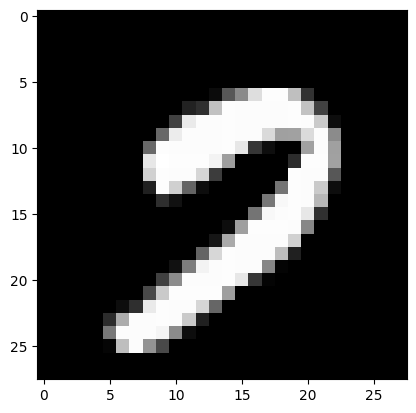

In [3]:
# ----- EDA -----
import random
idx = random.randint(0, len(train_dataset) - 1)
image, label = train_dataset[idx]

plt.imshow(image.squeeze(), cmap="gray")

In [4]:
# ----- Build the Neural Network model -----
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # nn.Sequential connects layers in order
        self.model = nn.Sequential(
            nn.Flatten(), # Flatten 28x28 image into a 784-element vector
            nn.Linear(in_features=28*28, out_features=128), # First hidden layer
            nn.ReLU(), # Activation function
            nn.Linear(in_features=128, out_features=10) # Output layer
        )
    def forward(self, x):
        return self.model(x)

model = SimpleNN()

# Define loss function and optimizer
loss_function = nn.CrossEntropyLoss() # Suitable for multiclass classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [5]:
# ----- Training loop -----
num_epochs = 5

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        outputs = model(images)
        loss = loss_function(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 200 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Step {i+1}/{len(train_loader)}, Loss: {loss.item():.4f}")

Epoch 1/5, Step 200/938, Loss: 0.4212
Epoch 1/5, Step 400/938, Loss: 0.3721
Epoch 1/5, Step 600/938, Loss: 0.1822
Epoch 1/5, Step 800/938, Loss: 0.1502
Epoch 2/5, Step 200/938, Loss: 0.2893
Epoch 2/5, Step 400/938, Loss: 0.0581
Epoch 2/5, Step 600/938, Loss: 0.1557
Epoch 2/5, Step 800/938, Loss: 0.1051
Epoch 3/5, Step 200/938, Loss: 0.0278
Epoch 3/5, Step 400/938, Loss: 0.0917
Epoch 3/5, Step 600/938, Loss: 0.0901
Epoch 3/5, Step 800/938, Loss: 0.0998
Epoch 4/5, Step 200/938, Loss: 0.0242
Epoch 4/5, Step 400/938, Loss: 0.0235
Epoch 4/5, Step 600/938, Loss: 0.0819
Epoch 4/5, Step 800/938, Loss: 0.0577
Epoch 5/5, Step 200/938, Loss: 0.0271
Epoch 5/5, Step 400/938, Loss: 0.0704
Epoch 5/5, Step 600/938, Loss: 0.0764
Epoch 5/5, Step 800/938, Loss: 0.0861


In [6]:
# ----- Evaluate the model on the test set -----
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        output = model(images)
        _, predicted = torch.max(output.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item() # Count correct predictions
    
accuracy = 100 * correct / total
print(f"Model accuracy on 10000 test images: {accuracy:.2f}%")

Model accuracy on 10000 test images: 97.48%


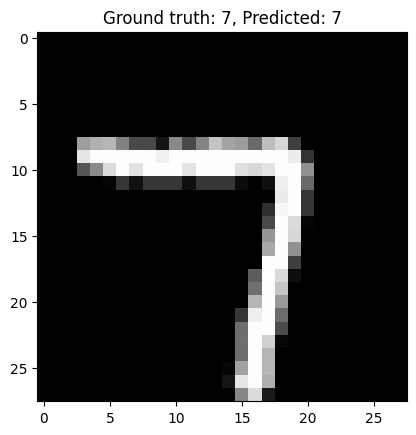

In [7]:
# ----- Test on a single image -----
idx = random.randint(0, len(test_dataset) - 1)
image, label = test_dataset[idx]

image_reshaped = image.unsqueeze(0)

with torch.no_grad():
    output = model(image_reshaped)
    _, predicted = torch.max(output.data, 1)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Ground truth: {label}, Predicted: {predicted.item()}")
plt.show()